# Aprendizaje por Refuerzo - Proyecto Final con ambiente de dos babitaciones
## Solución con Q-learning off-policy

---

**Ing. Daniel Arturo Martínez Morales** — Estudiante de maestría MIAD  
**Ing. Luis Miguel Ortega Cañate** — Estudiante de maestría MIAD  
Universidad de los Andes

---

### Descripción general

Este notebook implementa, entrena y evalúa un agente de **Q-learning** para resolver el problema de navegación en un ambiente de **dos habitaciones separadas por una puerta con llave**.

El agente debe completar una secuencia de subtareas:

1. Recoger la **bola** que bloquea la puerta  
2. Recoger la **llave azul**  
3. **Abrir la puerta** usando la llave  
4. Navegar hasta la **casilla de salida** en la habitación derecha  

---

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Imports y configuración |
| 2 | Definición del ambiente (`TwoRoomEnv`) |
| 3 | Agente Q-learning (`QLearningAgent`) |
| 4 | Persistencia de la Q-tabla |
| 5 | Entrenamiento |
| 6 | Curvas de aprendizaje |
| 7 | Evaluación y casos de prueba |
| 8 | Mapas de calor de la Q-tabla |
| 9 | Política óptima |
| 10 | Demostración animada |
| 11 | Resumen de resultados |


---
## 1. Imports y Configuración

Importamos las librerías necesarias y definimos las **constantes del ambiente**.  
El ambiente es una grilla de **9 columnas × 4 filas** con coordenadas `(col, row)`,  
donde `(0, 0)` está en la esquina inferior izquierda.


In [1]:
# Se importan las librerías necesarias para el entorno, el agente, y la visualización
import random, json, csv, os, time
import matplotlib
matplotlib.use('Agg')
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from IPython.display import Image, display
import numpy as np

# Dimensiones del ambiente y parámetros
NROWS     = 4          # filas  (y: 0 = inferior, 3 = superior)
NCOLS     = 9          # columnas totales
DOOR_COL  = 4          # columna de la pared divisoria / puerta
MAX_STEPS = 300        # pasos máximos por episodio (timeout)

# Posiciones fijas (col, row)
AGENT_START = (0, 0)   # posición inicial del agente
KEY_POS     = (3, 2)   # llave azul
BALL_POS    = (3, 0)   # bola roja (bloquea la puerta)
DOOR_POS    = (4, 0)   # la única celda de la pared que es puerta
EXIT_POS    = (6, 3)   # casilla de salida (desconocida para el agente)

# Acciones disponibles
ACTIONS = ['up', 'down', 'left', 'right', 'pick', 'drop', 'open_door']

print("Configuración cargada.")
print(f"Grilla: {NCOLS}×{NROWS}  |  Acciones: {len(ACTIONS)}  |  MAX_STEPS: {MAX_STEPS}")

Configuración cargada.
Grilla: 9×4  |  Acciones: 7  |  MAX_STEPS: 300


---
## 2. Definición del Ambiente: `TwoRoomEnv`

El ambiente se define conforme a lo ya indicado en el reporte de entrega parcial del proyecto de la semana 5 del curso.

### 2.1 Espacio de estados

El estado completo se representa como una tupla de 5 componentes:

```
S = (pos_agente, tiene_objeto, tipo_obj, bola_retirada, puerta_abierta)
```

| Variable | Tipo | Valores | Descripción |
|---|---|---|---|
| `pos_agente` | Discreta | `(col, row)` en `{0-8} × {0-3}` | Coordenadas (col, fila) del agente en la grilla. 9 columnas × 4 filas: habitación izquierda (cols 0–3), puerta (col 4), habitación derecha (cols 5–8). |
| `tiene_objeto` | Booleano | `{False, True}` | Indica si el agente carga algún objeto en su inventario. |
| `tipo_obj` | Categórico | `{None, 'bola', 'llave'}` | Tipo de objeto que lleva el agente. None si tiene_objeto=False. |
| `bola_retirada` | Booleano | `{False, True}` | Indica si la bola roja ya fue retirada del bloqueo de la puerta (recogida o desplazada). |
| `puerta_abierta` | Booleano | `{False, True}` | Indica si la puerta entre habitaciones está abierta. |

### 2.2 Restricciones de movimiento

- **Muros permanentes**: celdas `(4,1)`, `(4,2)`, `(4,3)` → siempre infranqueables.  
- **Puerta condicional**: celda `(4,0)` → traspasable solo si `door_open = True`.  
- El método `_is_wall(col, row)` centraliza toda la lógica de colisión.

### 2.3 Función de recompensa

| Evento | Recompensa |
|---|---|
| Recoger bola / llave (1ª vez) | +0.3 |
| Soltar bola | +0.1 |
| Abrir puerta | +0.5 |
| Cruzar la puerta | +0.2 |
| Alcanzar la salida | **+1.0** |
| Paso normal | −0.01 |
| Chocar con muro/borde | −0.02 |
| Intentar abrir sin precondiciones | −0.1 |
| Timeout | **−1.0** |


In [2]:
class TwoRoomEnv:
    def __init__(self):
        self.exit_pos = EXIT_POS
        self.reset()

    # Reset
    def reset(self):
        self.agent_pos    = AGENT_START
        self.has_object   = False
        self.object_type  = None
        self.ball_removed = False
        self.door_open    = False
        self.steps        = 0
        self.ball_map_pos = BALL_POS
        self.key_map_pos  = KEY_POS
        # Flags para evitar recompensas duplicadas en el mismo episodio
        self._rewarded_pick_ball  = False
        self._rewarded_pick_key   = False
        self._rewarded_open_door  = False
        self._rewarded_cross_door = False
        return self._get_state()

    def _get_state(self):
        return (self.agent_pos, self.has_object,
                self.object_type, self.ball_removed, self.door_open)

    # Lógica de muros
    def _is_wall(self, col, row):
        if col == DOOR_COL:
            if row != DOOR_POS[1]:
                return True
            return not self.door_open
        return False

    # Acciones posibles
    def get_possible_actions(self):
        col, row = self.agent_pos
        actions  = []
        if row < NROWS - 1 and not self._is_wall(col, row + 1): actions.append('up')
        if row > 0          and not self._is_wall(col, row - 1): actions.append('down')
        if col > 0          and not self._is_wall(col - 1, row): actions.append('left')
        if col < NCOLS - 1  and not self._is_wall(col + 1, row): actions.append('right')
        if not self.has_object:
            if self.ball_map_pos == self.agent_pos and not self.ball_removed:
                actions.append('pick')
            if self.key_map_pos == self.agent_pos:
                actions.append('pick')
        if self.has_object:
            actions.append('drop')
        actions.append('open_door')
        return actions

    # Step
    def step(self, action: str):
        self.steps += 1
        col, row = self.agent_pos
        reward, done, info = 0.0, False, ""

        if action in ('up', 'down', 'left', 'right'):
            nc, nr = col, row
            if   action == 'up':    nr += 1
            elif action == 'down':  nr -= 1
            elif action == 'left':  nc -= 1
            elif action == 'right': nc += 1

            if not (0 <= nc < NCOLS and 0 <= nr < NROWS):
                reward, info = -0.02, "pared_borde"
            elif self._is_wall(nc, nr):
                reward = -0.02
                info   = "puerta_cerrada" if (nc == DOOR_COL and nr == DOOR_POS[1]) else "muro"
            else:
                self.agent_pos = (nc, nr)
                if col == DOOR_COL and nc > DOOR_COL and not self._rewarded_cross_door:
                    reward += 0.2; self._rewarded_cross_door = True; info = "cruzo_puerta"
                if self.agent_pos == self.exit_pos:
                    reward += 1.0; done = True; info = "salida_alcanzada"
                elif info == "":
                    reward = -0.01

        elif action == 'pick':
            if self.has_object:
                reward, info = -0.05, "ya_carga_objeto"
            elif self.ball_map_pos == self.agent_pos and not self.ball_removed:
                if self._rewarded_pick_ball:
                    reward, info = -0.05, "bola_ya_recogida"
                else:
                    self.has_object, self.object_type, self.ball_removed = True, 'bola', True
                    reward = 0.3; self._rewarded_pick_ball = True; info = "recogió_bola"
            elif self.key_map_pos == self.agent_pos:
                if self._rewarded_pick_key:
                    reward, info = -0.05, "llave_ya_recogida"
                else:
                    self.has_object, self.object_type = True, 'llave'
                    reward = 0.3; self._rewarded_pick_key = True; info = "recogió_llave"
            else:
                reward, info = -0.01, "nada_que_recoger"

        elif action == 'drop':
            if not self.has_object:
                reward, info = -0.01, "no_carga_nada"
            else:
                if self.object_type == 'bola':
                    self.ball_map_pos = self.agent_pos; reward = 0.1; info = "soltó_bola"
                else:
                    self.key_map_pos = self.agent_pos; reward = -0.01; info = "soltó_llave"
                self.has_object, self.object_type = False, None

        elif action == 'open_door':
            adj = (col == DOOR_COL - 1 and row == DOOR_POS[1])
            can_open = adj and self.has_object and self.object_type == 'llave' \
                       and self.ball_removed and not self.door_open
            if can_open:
                self.door_open = True; reward = 0.5
                self._rewarded_open_door = True; info = "abrió_puerta"
            else:
                reward, info = -0.1, "no_puede_abrir"

        if self.steps >= MAX_STEPS and not done:
            reward += -1.0; done = True; info += "|timeout"

        return self._get_state(), reward, done, info

    def is_terminal(self, state=None):
        if state is None:
            return self.agent_pos == self.exit_pos or self.steps >= MAX_STEPS
        return state[0] == self.exit_pos

    # Render
    def render(self, ax=None, title=""):
        if ax is None:
            fig, ax = plt.subplots(figsize=(11, 5))
        else:
            fig = ax.get_figure()
        ax.clear()
        ax.set_xlim(0, NCOLS); ax.set_ylim(0, NROWS)
        ax.set_aspect('equal'); ax.set_facecolor('#1a1a2e')
        fig.patch.set_facecolor('#0f0f1a')

        ax.add_patch(plt.Rectangle((0,0), DOOR_COL, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL+1,0), NCOLS-DOOR_COL-1, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL, 1), 1, NROWS-1, color='#475569', zorder=1))
        for x in range(NCOLS+1): ax.axvline(x, color='#475569', lw=0.5, zorder=2)
        for y in range(NROWS+1): ax.axhline(y, color='#475569', lw=0.5, zorder=2)

        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc,dr),1,1,
            color='#2563eb' if self.door_open else '#1e3a5f', zorder=3))
        ax.text(dc+0.5, dr+0.5, 'OPEN' if self.door_open else 'LOCK',
                ha='center', va='center', color='white', fontsize=7, fontweight='bold', zorder=4)

        if not self.ball_removed:
            bx, by = self.ball_map_pos
            ax.add_patch(plt.Circle((bx+0.5, by+0.5), 0.28, color='#ef4444', zorder=3))
            ax.text(bx+0.5, by+0.5, 'B', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold', zorder=4)
        elif not (self.has_object and self.object_type == 'bola'):
            bx, by = self.ball_map_pos
            ax.add_patch(plt.Circle((bx+0.5, by+0.5), 0.25, color='#ef4444', alpha=0.4, zorder=3))

        if not (self.has_object and self.object_type == 'llave'):
            kx, ky = self.key_map_pos
            ax.add_patch(plt.Circle((kx+0.5, ky+0.5), 0.25, color='#3b82f6', zorder=3))
            ax.text(kx+0.5, ky+0.5, 'K', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold', zorder=4)

        ex, ey = self.exit_pos
        ax.add_patch(plt.Rectangle((ex,ey),1,1, color='#16a34a', alpha=0.7, zorder=3))
        ax.text(ex+0.5, ey+0.5, 'EXIT', ha='center', va='center',
                color='white', fontsize=7, fontweight='bold', zorder=4)

        ax_, ay_ = self.agent_pos
        ax.add_patch(plt.Circle((ax_+0.5, ay_+0.5), 0.32,
                     color='#f59e0b' if self.has_object else '#a78bfa', zorder=5))
        ax.text(ax_+0.5, ay_+0.5, {'bola':'B','llave':'K'}.get(self.object_type,'A'),
                ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=6)

        ax.set_title(title, color='white', fontsize=10, pad=6)
        ax.set_xticks(range(NCOLS)); ax.set_xticklabels(range(NCOLS), color='#64748b', fontsize=7)
        ax.set_yticks(range(NROWS)); ax.set_yticklabels(range(NROWS), color='#64748b', fontsize=7)
        s = self._get_state()
        ax.set_xlabel(f"Pos:{s[0]}  Obj:{s[2] or '-'}  BalaRet:{s[3]}  Puerta:{s[4]}  Paso:{self.steps}",
                      color='#94a3b8', fontsize=8)
        return fig, ax

print("Ambiente TwoRoomEnv definido.")

Ambiente TwoRoomEnv definido.


### 2.4 Visualización del ambiente inicial

Creamos una instancia del ambiente y lo renderizamos en su estado inicial para verificar que la grilla se construye correctamente.


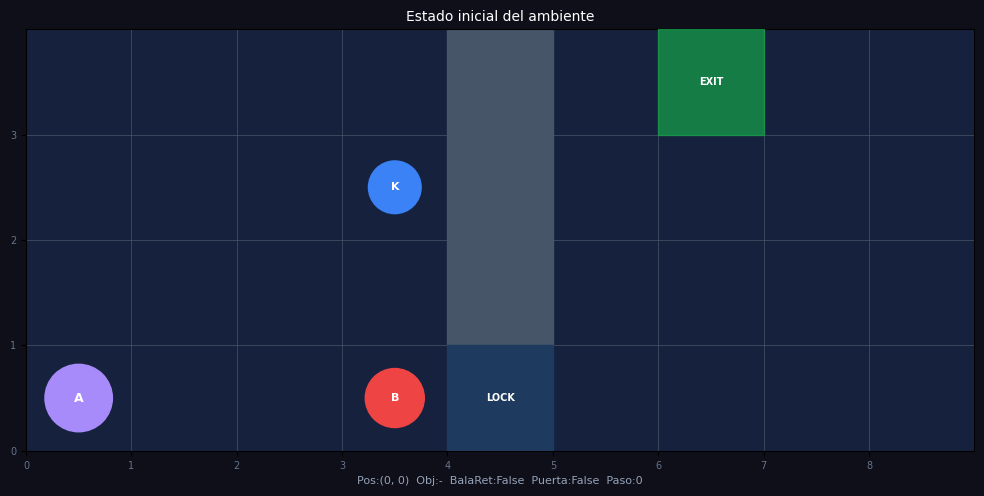

Leyenda: A=Agente (morado) | B=Bola roja | K=Llave azul | EXIT=Salida verde | LOCK=Puerta cerrada

Estado inicial: ((0, 0), False, None, False, False)


In [3]:
env_demo = TwoRoomEnv()
fig, ax = env_demo.render(title="Estado inicial del ambiente")
plt.tight_layout()
plt.show()
print("Leyenda: A=Agente (morado) | B=Bola roja | K=Llave azul | EXIT=Salida verde | LOCK=Puerta cerrada")
print(f"\nEstado inicial: {env_demo._get_state()}")


---
## 3. Agente Q-learning - `QLearningAgent`

### 3.1 Algoritmo Q-learning off-policy

Q-learning actualiza los valores usando la **mejor acción posible** en el estado siguiente, sin importar qué acción se tomará realmente (por eso es *off-policy*).

$$
Q(s,a) \leftarrow (1-\alpha)Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a')\right]
$$

### 3.2 Política ε-greedy

* Con probabilidad **ε** se tomará una acción aleatoria (exploración)
* Con probabilidad **1-ε** se tomara la mejor acción conocida (explotación)

### 3.3 Epsilon decay

Cada 100 episodios:

$$
\varepsilon \leftarrow \max(\varepsilon_{\min}, \varepsilon/10)
$$

Esto genera una transición suave de exploración total a explotación casi completa.

### 3.4 Hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| `epsilon` inicial | 0.9 | Alta exploración al inicio |
| `epsilon` mínimo | 0.01 | 1% de exploración residual |
| `gamma` | 0.9 | Valora recompensas futuras |
| `alpha` | 0.5 | Aprendizaje moderado |
| Episodios | 20,000 | Cobertura suficiente |


In [4]:
# Definición del agente Q-learning
class QLearningAgent:
    def __init__(self, env, epsilon=0.9, gamma=0.9, alpha=0.5):
        self.env     = env
        self.epsilon = epsilon
        self.gamma   = gamma
        self.alpha   = alpha
        self.qtable  = {}

    # Acceso a la Q-tabla
    def get_value(self, state, action) -> float:
        return self.qtable.get((state, action), 0.0)

    def set_value(self, state, action, value):
        self.qtable[(state, action)] = value

    # Selección de acción
    def best_action(self, state) -> str:
        possible = self.env.get_possible_actions()
        q_vals   = [self.get_value(state, a) for a in possible]
        max_q    = max(q_vals)
        best     = [a for a, q in zip(possible, q_vals) if q == max_q]
        return random.choice(best)

    def choose_action(self, state) -> str:
        if random.random() < self.epsilon:
            return random.choice(self.env.get_possible_actions())
        return self.best_action(state)

    # Actualización Q-learning
    def update_values(self, state, action, next_state, reward):
        cq  = self.get_value(state, action)
        mnq = 0.0 if self.env.is_terminal(next_state) else \
              max(self.get_value(next_state, a) for a in ACTIONS)
        self.set_value(state, action,
                       (1 - self.alpha) * cq + self.alpha * (reward + self.gamma * mnq))

    def step(self, action):
        return self.env.step(action)

    # Entrenamiento
    def run(self, episodes=20000, decay_interval=100, epsilon_min=0.01, verbose=True):
        history = {'rewards': [], 'steps': [], 'successes': []}
        for ep in range(episodes):
            state  = self.env.reset()
            total  = 0.0; done = False; success = False
            while not done:
                action = self.choose_action(state)
                ns, r, done, info = self.step(action)
                self.update_values(state, action, ns, r)
                state = ns; total += r
                if 'salida_alcanzada' in info: success = True
            history['rewards'].append(total)
            history['steps'].append(self.env.steps)
            history['successes'].append(int(success))
            # Epsilon decay cada 'decay_interval' episodios
            if (ep + 1) % decay_interval == 0 and self.epsilon > epsilon_min:
                self.epsilon = max(epsilon_min, self.epsilon - self.epsilon / 10)
            if verbose and (ep + 1) % 2000 == 0:
                w  = min(2000, ep + 1)
                rr = history['rewards'][-w:]
                ss = history['successes'][-w:]
                print(f"  Ep {ep+1:>6} | ε={self.epsilon:.4f} | "
                      f"R_avg={sum(rr)/len(rr):>7.3f} | Éxitos={sum(ss)}/{w}")
        return history

    # Evaluación
    def evaluate(self, n=20):
        saved = self.epsilon; self.epsilon = 0.0
        rewards, steps_l, succs = [], [], []
        for _ in range(n):
            state = self.env.reset(); done = False; total = 0.0; suc = False
            while not done:
                action = self.best_action(state)
                state, r, done, info = self.step(action)
                total += r
                if 'salida_alcanzada' in info: suc = True
            rewards.append(total); steps_l.append(self.env.steps); succs.append(int(suc))
        self.epsilon = saved
        return sum(rewards)/n, sum(steps_l)/n, sum(succs)/n

print("Agente QLearningAgent definido.")

Agente QLearningAgent definido.


---
## 4. Persistencia de la Q-tabla

Se implementan funciones para guardar y cargar la Q-tabla en dos formatos:

- **JSON** — formato legible y recargable; permite continuar entrenamiento o cargar un agente ya entrenado.  
- **CSV** — formato tabular ordenado por Q-valor; ideal para análisis en Excel o pandas.


In [5]:
def save_qtable_json(agent, path="qtable.json"):
    out = {}
    for (state, action), val in agent.qtable.items():
        key = json.dumps([list(state[0]), state[1], state[2], state[3], state[4]])
        out.setdefault(key, {})[action] = round(val, 6)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(out, f, indent=2)
    print(f"Q-tabla guardada → '{path}'  ({len(agent.qtable)} entradas)")

def load_qtable_json(agent, path="qtable.json"):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    agent.qtable = {}
    for key_str, acts in data.items():
        r = json.loads(key_str)
        state = (tuple(r[0]), r[1], r[2], r[3], r[4])
        for action, val in acts.items():
            agent.qtable[(state, action)] = val
    print(f"Q-tabla cargada  ← '{path}'  ({len(agent.qtable)} entradas)")

def save_qtable_csv(agent, path="qtable.csv"):
    with open(path, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['pos_col','pos_row','tiene_objeto','tipo_obj',
                    'bola_retirada','puerta_abierta','accion','q_valor'])
        for (state, action), val in sorted(agent.qtable.items(),
                                            key=lambda x: x[1], reverse=True):
            pos, ho, ot, br, da = state
            w.writerow([pos[0], pos[1], ho, ot, br, da, action, f"{val:.6f}"])
    print(f"Q-tabla guardada → '{path}'  ({len(agent.qtable)} entradas)")

print("Funciones de persistencia definidas.")

Funciones de persistencia definidas.



---
## 5. Entrenamiento del Agente

Creamos el ambiente y el agente con los hiperparámetros óptimos y ejecutamos **20,000 episodios** de Q-learning.

Durante el entrenamiento se registran por episodio:
- Recompensa acumulada
- Número de pasos
- Éxito (1 si llegó a la salida, 0 si timeout)



In [6]:
# Crear ambiente y agente
env   = TwoRoomEnv()
agent = QLearningAgent(env, epsilon=0.9, gamma=0.9, alpha=0.5)

# Entrenar
EPISODES = 20000
print(f"Entrenando {EPISODES:,} episodios...")
t0      = time.time()
history = agent.run(EPISODES, decay_interval=100, epsilon_min=0.01, verbose=True)
elapsed = time.time() - t0

print(f"\nTiempo de entrenamiento : {elapsed:.1f}s")
print(f"Entradas en Q-tabla      : {len(agent.qtable)}")
print(f"Epsilon final            : {agent.epsilon:.4f}")

Entrenando 20,000 episodios...
  Ep   2000 | ε=0.1094 | R_avg= -3.131 | Éxitos=1035/2000
  Ep   4000 | ε=0.0133 | R_avg=  1.478 | Éxitos=1884/2000
  Ep   6000 | ε=0.0100 | R_avg=  1.692 | Éxitos=1907/2000
  Ep   8000 | ε=0.0100 | R_avg=  1.842 | Éxitos=1924/2000
  Ep  10000 | ε=0.0100 | R_avg=  1.614 | Éxitos=1890/2000
  Ep  12000 | ε=0.0100 | R_avg=  1.770 | Éxitos=1919/2000
  Ep  14000 | ε=0.0100 | R_avg=  1.697 | Éxitos=1898/2000
  Ep  16000 | ε=0.0100 | R_avg=  1.896 | Éxitos=1931/2000
  Ep  18000 | ε=0.0100 | R_avg=  1.322 | Éxitos=1835/2000
  Ep  20000 | ε=0.0100 | R_avg=  2.089 | Éxitos=1963/2000

Tiempo de entrenamiento : 6.2s
Entradas en Q-tabla      : 561
Epsilon final            : 0.0100


In [7]:
# Guardar Q-tabla
save_qtable_json(agent, "qtable.json")
save_qtable_csv(agent,  "qtable.csv")

Q-tabla guardada → 'qtable.json'  (561 entradas)
Q-tabla guardada → 'qtable.csv'  (561 entradas)


---
## 6. Curvas de Aprendizaje

Las curvas muestran cómo evoluciona el agente a lo largo del entrenamiento.  
Se trazan tres métricas con **media móvil** para suavizar la variabilidad episódica.

**Tres fases identificables:**
1. **Exploración** (ep 0–2000, ε ≈ 0.9→0.1): el agente explora aleatoriamente; recompensa negativa.  
2. **Transición** (ep 2000–4000, ε ≈ 0.1→0.01): combina conocimiento adquirido con algo de exploración; la tasa de éxito sube rápidamente.  
3. **Explotación** (ep 4000+, ε ≈ 0.01): convergencia a la política óptima; éxito sostenido >93%.


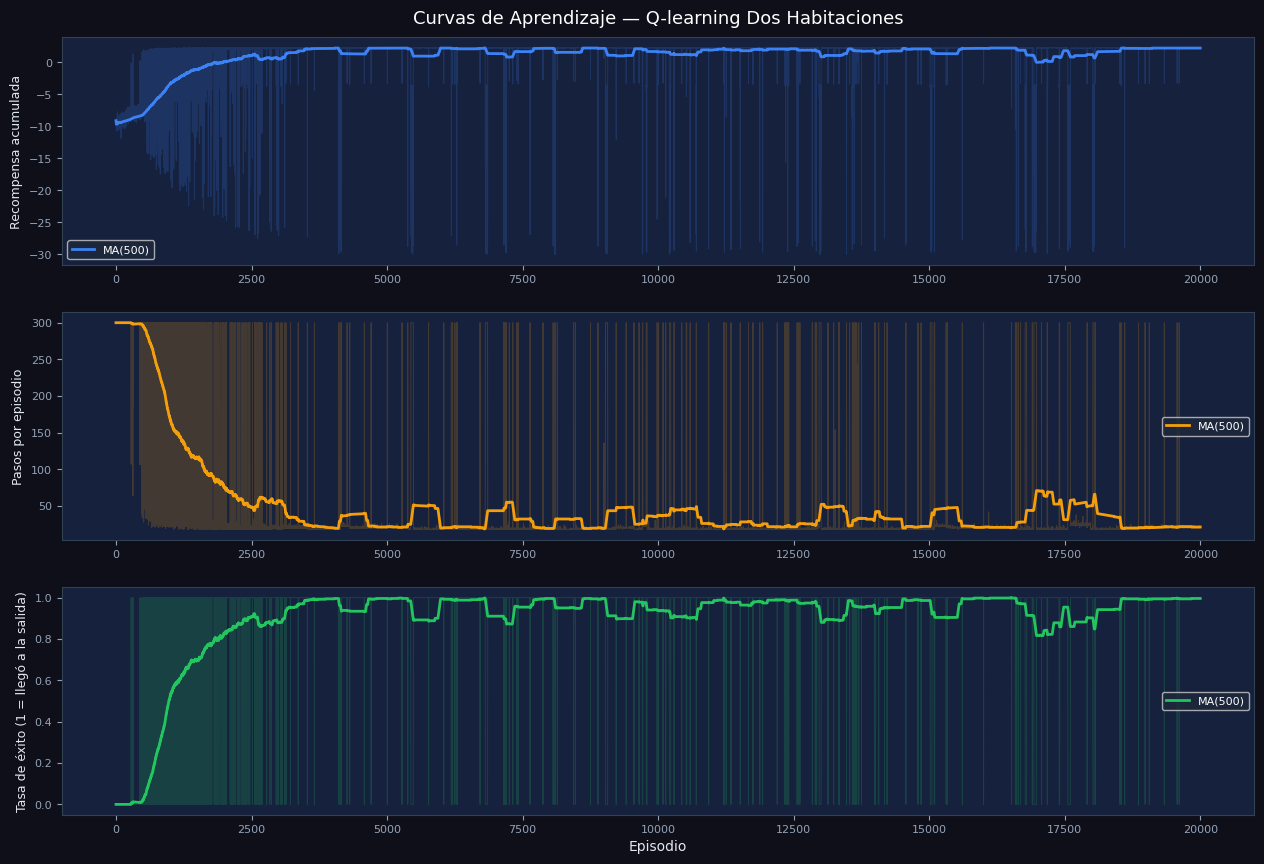

In [8]:
def plot_training_inline(history):
    R = history['rewards']; S = history['steps']; X = history['successes']
    n = len(R); w = max(1, min(500, n // 10))

    def ma(d):
        out = []
        for i in range(len(d)):
            sl = d[max(0, i-w):i+1]
            out.append(sum(sl) / len(sl))
        return out

    fig, axes = plt.subplots(3, 1, figsize=(13, 9))
    fig.patch.set_facecolor('#0f0f1a')
    specs = [(R, '#3b82f6', 'Recompensa acumulada'),
             (S, '#f59e0b', 'Pasos por episodio'),
             (X, '#22c55e', 'Tasa de éxito (1 = llegó a la salida)')]
    for ax, (d, c, yl) in zip(axes, specs):
        ax.set_facecolor('#16213e')
        ax.plot(d,     color=c, alpha=0.2, lw=0.7)
        ax.plot(ma(d), color=c, lw=2.0, label=f'MA({w})')
        ax.set_ylabel(yl, color='#e2e8f0', fontsize=9)
        ax.tick_params(colors='#94a3b8', labelsize=8)
        for sp in ax.spines.values(): sp.set_color('#334155')
        ax.legend(facecolor='#1e293b', labelcolor='white', fontsize=8)
    axes[0].set_title('Curvas de Aprendizaje — Q-learning Dos Habitaciones',
                      color='white', fontsize=13, pad=10)
    axes[2].set_xlabel('Episodio', color='#e2e8f0', fontsize=10)
    plt.tight_layout(pad=2)
    plt.show()

plot_training_inline(history)

---
## 7. Evaluación y Casos de Prueba

### 7.1 Evaluación cuantitativa

Corremos **20 episodios** con `ε = 0` (pura explotación) para medir el desempeño real del agente entrenado.


In [9]:
avg_r, avg_s, sr = agent.evaluate(n=20)
print("━"*45)
print(f"  {'Métrica':<28} {'Valor':>10}")
print("━"*45)
print(f"  {'Tasa de éxito':<28} {sr*100:>9.1f}%")
print(f"  {'Recompensa promedio':<28} {avg_r:>10.3f}")
print(f"  {'Pasos promedio':<28} {avg_s:>10.1f}")
print(f"  {'Recompensa máx. teórica':<28} {'2.40':>10}")
print(f"  {'Eficiencia vs. óptimo':<28} {avg_r/2.4*100:>9.1f}%")
print("━"*45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Métrica                           Valor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tasa de éxito                    100.0%
  Recompensa promedio               2.260
  Pasos promedio                     20.0
  Recompensa máx. teórica            2.40
  Eficiencia vs. óptimo             94.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 7.2 Trayectorias de casos de prueba

Visualizamos **3 episodios completos** de evaluación.  
La línea naranja muestra el camino recorrido (más opaca = paso más reciente).

**Símbolos en el mapa:**
- `B` = recogió bola &nbsp;&nbsp; `K` = recogió llave &nbsp;&nbsp; `O` = abrió puerta &nbsp;&nbsp; `X` = cruzó puerta &nbsp;&nbsp; `★` = llegó a la salida


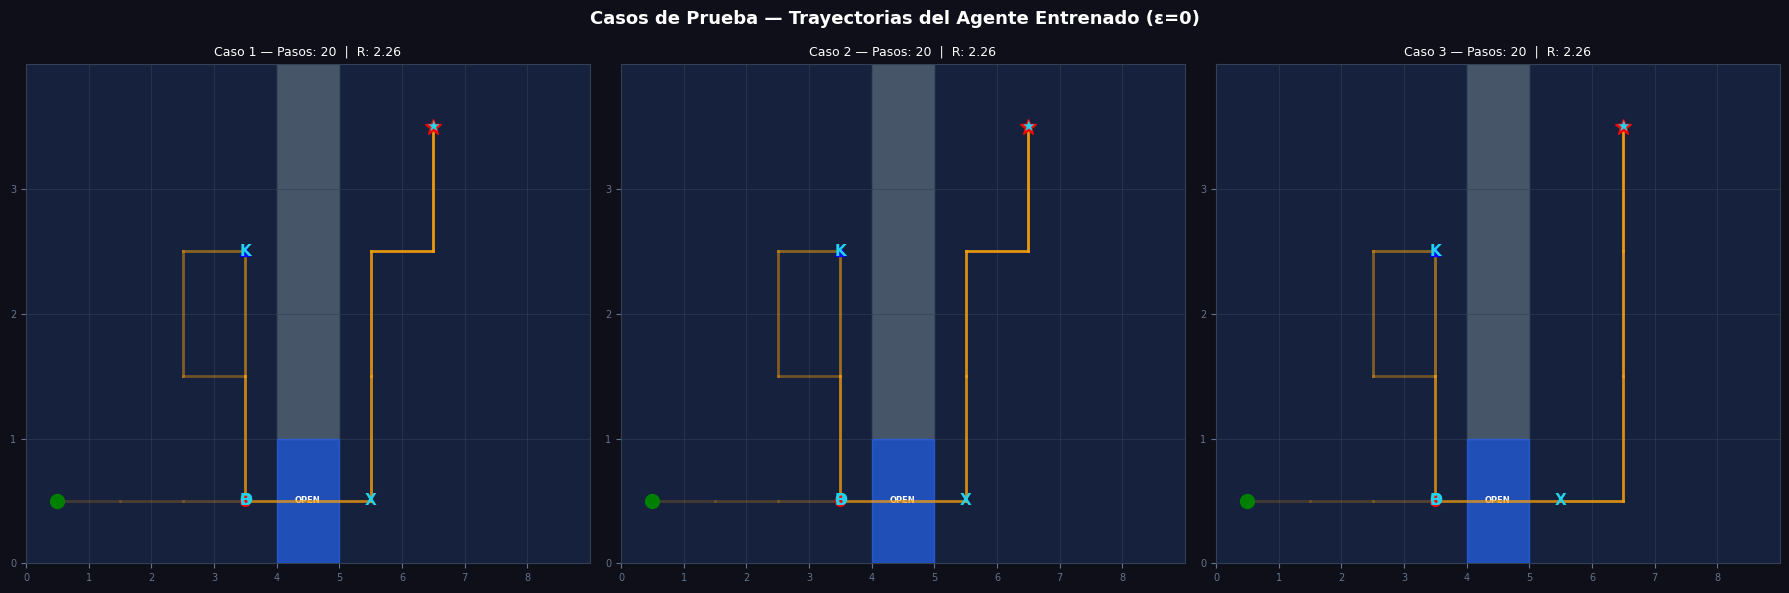

In [10]:
_HITO_SYM = {'recogió_bola':'B', 'recogió_llave':'K',
             'abrió_puerta':'O', 'cruzo_puerta':'X', 'salida_alcanzada':'★'}

def plot_test_cases(agent, n=3):
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0

    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Casos de Prueba — Trayectorias del Agente Entrenado (ε=0)',
                 color='white', fontsize=13, fontweight='bold')

    for ep_idx, ax in enumerate(axes):
        env2 = TwoRoomEnv()
        ag2  = QLearningAgent(env2, epsilon=0.0)
        ag2.qtable = agent.qtable

        state   = env2.reset()
        traj    = [env2.agent_pos]
        hitos   = []
        done    = False; total_r = 0.0

        while not done:
            action = ag2.best_action(state)
            state, r, done, info = ag2.step(action)
            traj.append(env2.agent_pos)
            total_r += r
            if info in _HITO_SYM:
                hitos.append((env2.agent_pos, info))

        ax.set_facecolor('#16213e')
        ax.add_patch(plt.Rectangle((0,0), DOOR_COL, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL+1,0), NCOLS-DOOR_COL-1, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL,1), 1, NROWS-1, color='#475569', zorder=1))
        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc,dr),1,1, color='#2563eb', alpha=0.7, zorder=2))
        ax.text(dc+0.5, dr+0.5, 'OPEN', ha='center', va='center',
                color='white', fontsize=6, fontweight='bold', zorder=3)
        for x in range(NCOLS+1): ax.axvline(x, color='#334155', lw=0.4, zorder=1)
        for y in range(NROWS+1): ax.axhline(y, color='#334155', lw=0.4, zorder=1)

        xs = [p[0]+0.5 for p in traj]; ys = [p[1]+0.5 for p in traj]
        for i in range(len(xs)-1):
            alpha = 0.2 + 0.8 * (i / max(len(xs)-1, 1))
            ax.plot(xs[i:i+2], ys[i:i+2], color='#f59e0b', lw=2, alpha=alpha, zorder=4)
        ax.plot(xs[0], ys[0], 'go', ms=10, zorder=6)
        ax.plot(xs[-1], ys[-1], 'r*', ms=12, zorder=6)

        for pos, info in hitos:
            ax.text(pos[0]+0.5, pos[1]+0.5, _HITO_SYM[info], ha='center', va='center',
                    fontsize=11, color='#22d3ee', fontweight='bold', zorder=7)

        ax.plot(BALL_POS[0]+0.5, BALL_POS[1]+0.5, 'ro', ms=7, zorder=5)
        ax.plot(KEY_POS[0]+0.5,  KEY_POS[1]+0.5,  'b^', ms=7, zorder=5)
        ax.plot(EXIT_POS[0]+0.5, EXIT_POS[1]+0.5, 'g*', ms=10, zorder=5)

        ax.set_xlim(0, NCOLS); ax.set_ylim(0, NROWS)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        ax.set_title(f'Caso {ep_idx+1} — Pasos: {env2.steps}  |  R: {total_r:.2f}',
                     color='white', fontsize=9)
        for sp in ax.spines.values(): sp.set_color('#334155')

    agent.epsilon = saved_eps
    plt.tight_layout()
    plt.show()

plot_test_cases(agent, n=3)

---
## 8. Mapas de Calor de la Q-tabla

Para cada una de las **6 fases del episodio** (combinaciones de estado discreto)  
se muestra el **Q-valor máximo** alcanzable desde cada posición.

- 🟢 **Verde** = alto valor (cerca del objetivo)  
- 🔴 **Rojo** = bajo valor (lejos o con penalizaciones)  
- `W` = muro permanente | `L` = puerta cerrada

**Lectura recomendada:** observar cómo el gradiente de valores cambia entre fases,  
guiando al agente hacia la subtarea correcta en cada momento.


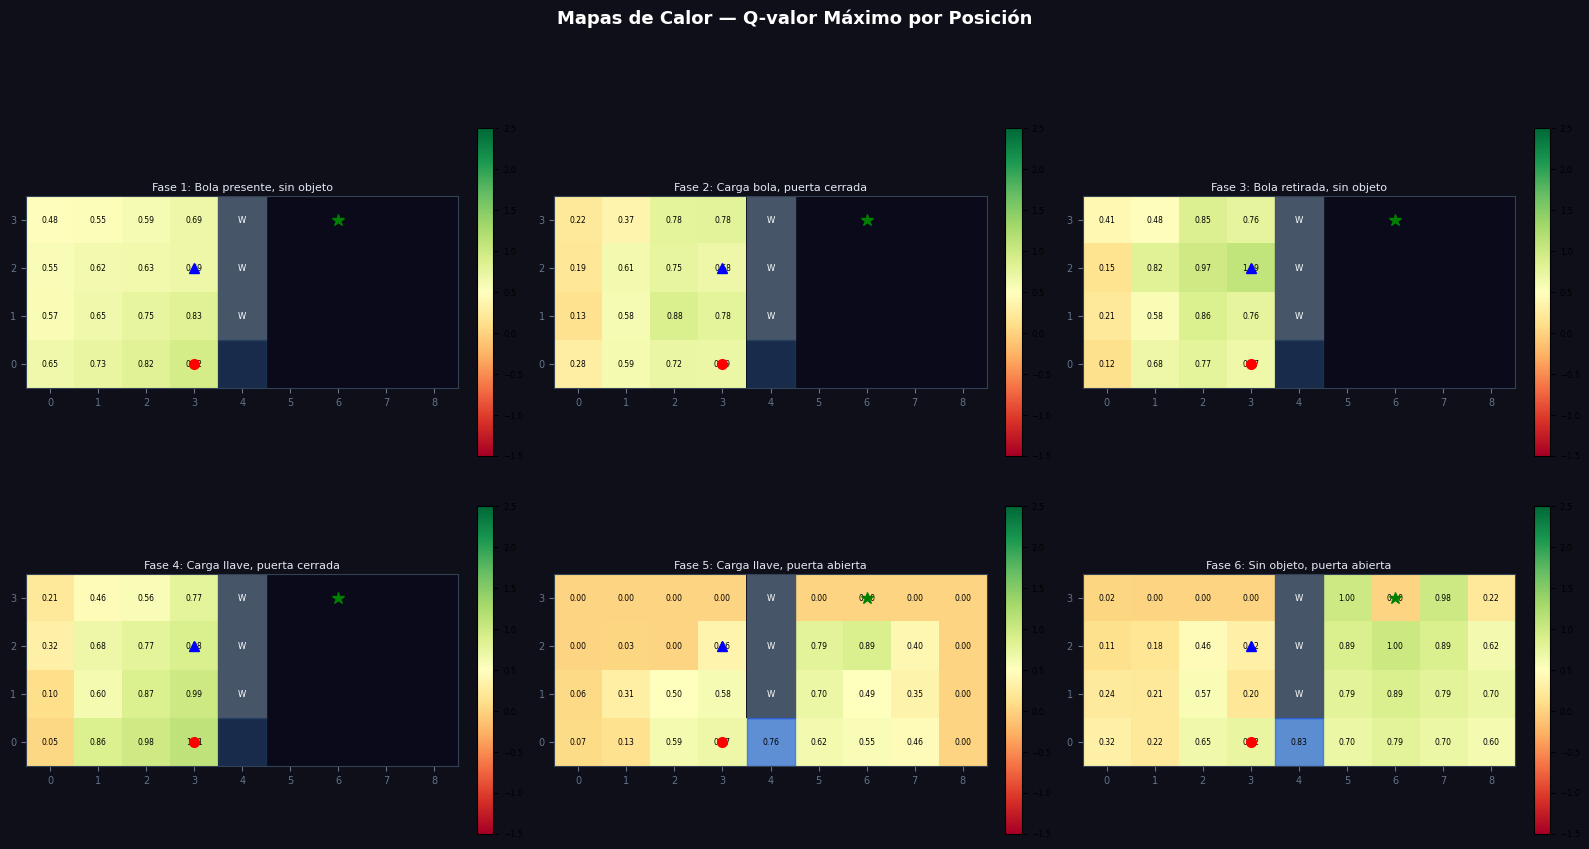

In [11]:
_STATE_COMBOS = [
    (False, False, None,    'Fase 1: Bola presente, sin objeto'),
    (True,  False, 'bola',  'Fase 2: Carga bola, puerta cerrada'),
    (True,  False, None,    'Fase 3: Bola retirada, sin objeto'),
    (True,  False, 'llave', 'Fase 4: Carga llave, puerta cerrada'),
    (True,  True,  'llave', 'Fase 5: Carga llave, puerta abierta'),
    (True,  True,  None,    'Fase 6: Sin objeto, puerta abierta'),
]

def plot_heatmaps(agent):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Mapas de Calor — Q-valor Máximo por Posición',
                 color='white', fontsize=13, fontweight='bold', y=0.98)

    for ax, (ball_ret, door_open, obj_type, title) in zip(axes.flat, _STATE_COMBOS):
        grid    = np.full((NROWS, NCOLS), np.nan)
        has_obj = obj_type is not None
        for row in range(NROWS):
            for col in range(NCOLS):
                if col == DOOR_COL and row != DOOR_POS[1]: continue
                if col == DOOR_COL and not door_open:      continue
                if col > DOOR_COL  and not door_open:      continue
                state = ((col, row), has_obj, obj_type, ball_ret, door_open)
                grid[row, col] = max(agent.get_value(state, a) for a in ACTIONS)

        ax.set_facecolor('#0a0a1a')
        im = ax.imshow(grid, cmap='RdYlGn', vmin=-1.5, vmax=2.5,
                       origin='lower', aspect='equal')

        for r in range(NROWS):
            for c in range(NCOLS):
                if c == DOOR_COL and r != DOOR_POS[1]:
                    ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#475569', zorder=2))
                    ax.text(c, r, 'W', ha='center', va='center', color='white', fontsize=6, zorder=3)
                elif not np.isnan(grid[r, c]):
                    ax.text(c, r, f'{grid[r,c]:.2f}', ha='center', va='center',
                            fontsize=5.5, color='black', zorder=4)

        ax.plot(*BALL_POS, 'ro', ms=7, zorder=5)
        ax.plot(*KEY_POS,  'b^', ms=7, zorder=5)
        ax.plot(*EXIT_POS, 'g*', ms=9, zorder=5)
        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc-0.5, dr-0.5), 1, 1,
                     color='#2563eb' if door_open else '#1e3a5f', alpha=0.7, zorder=2))

        ax.set_title(title, color='#e2e8f0', fontsize=8, pad=4)
        ax.set_xlim(-0.5, NCOLS-0.5); ax.set_ylim(-0.5, NROWS-0.5)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        for sp in ax.spines.values(): sp.set_color('#334155')
        plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04).ax.tick_params(labelsize=6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_heatmaps(agent)

---
## 9. Política Óptima Aprendida

Para cada posición y fase mostramos la **mejor acción** según la Q-tabla.  
El color de fondo indica el tipo de acción:

| Color | Acción |
|---|---|
| 🔵 Azul | `up` ↑ |
| 🟡 Amarillo | `down` ↓ |
| 🟣 Morado | `left` ← |
| 🟢 Verde | `right` → |
| 🔴 Rojo | `pick` (P) — recoger |
| 🟠 Naranja | `drop` (D) — soltar |
| 🩵 Cian | `open_door` (O) — abrir puerta |

**Observación clave:** en la Fase 4 la acción `O` aparece en la celda `(3,0)`,  
confirmando que el agente aprendió correctamente la posición exacta para abrir la puerta.


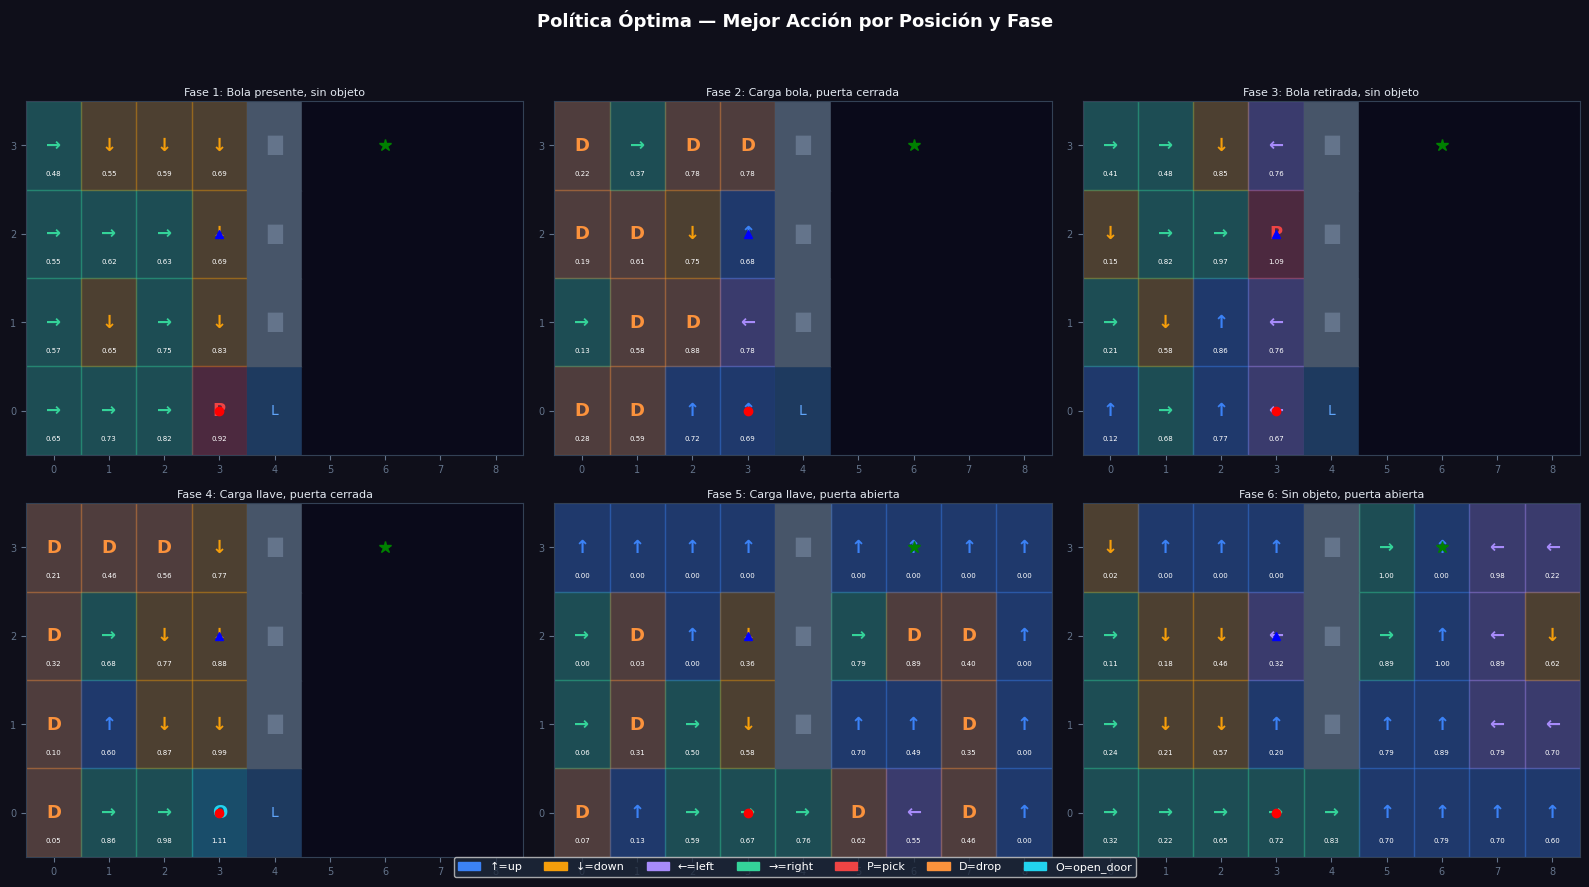

In [12]:
_ACT_ARROWS = {'up':'↑','down':'↓','left':'←','right':'→',
               'pick':'P','drop':'D','open_door':'O'}
_ACT_COLORS = {'up':'#3b82f6','down':'#f59e0b','left':'#a78bfa',
               'right':'#34d399','pick':'#ef4444','drop':'#fb923c',
               'open_door':'#22d3ee'}

def plot_policy_map(agent):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Política Óptima — Mejor Acción por Posición y Fase',
                 color='white', fontsize=13, fontweight='bold', y=0.98)

    for ax, (ball_ret, door_open, obj_type, title) in zip(axes.flat, _STATE_COMBOS):
        ax.set_facecolor('#16213e')
        has_obj = obj_type is not None
        for row in range(NROWS):
            for col in range(NCOLS):
                if col == DOOR_COL and row != DOOR_POS[1]:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#475569',zorder=1))
                    ax.text(col, row, '█', ha='center', va='center', color='#64748b', fontsize=14, zorder=2)
                    continue
                if col == DOOR_COL and not door_open:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#1e3a5f',zorder=1))
                    ax.text(col, row, 'L', ha='center', va='center', color='#60a5fa', fontsize=10, zorder=2)
                    continue
                if col > DOOR_COL and not door_open:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#0a0a1a',zorder=1))
                    continue
                state  = ((col, row), has_obj, obj_type, ball_ret, door_open)
                q_vals = [(agent.get_value(state, a), a) for a in ACTIONS]
                bq, best_a = max(q_vals)
                ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,
                    color=_ACT_COLORS[best_a], alpha=0.25, zorder=1))
                ax.text(col, row, _ACT_ARROWS[best_a], ha='center', va='center',
                        fontsize=13, color=_ACT_COLORS[best_a], fontweight='bold', zorder=3)
                ax.text(col, row-0.32, f'{bq:.2f}', ha='center', va='center',
                        fontsize=5, color='white', zorder=3)
        ax.plot(*BALL_POS,'ro',ms=6,zorder=5); ax.plot(*KEY_POS,'b^',ms=6,zorder=5)
        ax.plot(*EXIT_POS,'g*',ms=9,zorder=5)
        ax.set_xlim(-0.5,NCOLS-0.5); ax.set_ylim(-0.5,NROWS-0.5)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        ax.set_title(title, color='#e2e8f0', fontsize=8, pad=4)
        for sp in ax.spines.values(): sp.set_color('#334155')

    patches = [mpatches.Patch(color=c, label=f'{_ACT_ARROWS[a]}={a}')
               for a, c in _ACT_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=7,
               facecolor='#1e293b', labelcolor='white', fontsize=8,
               bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_policy_map(agent)

### 9.1 Top 20 pares (Estado, Acción) por Q-valor

Los pares con mayor Q-valor corresponden exactamente a las acciones críticas del problema:  
`pick` en bola/llave, `open_door` desde `(3,0)`, y movimientos directos hacia la salida.


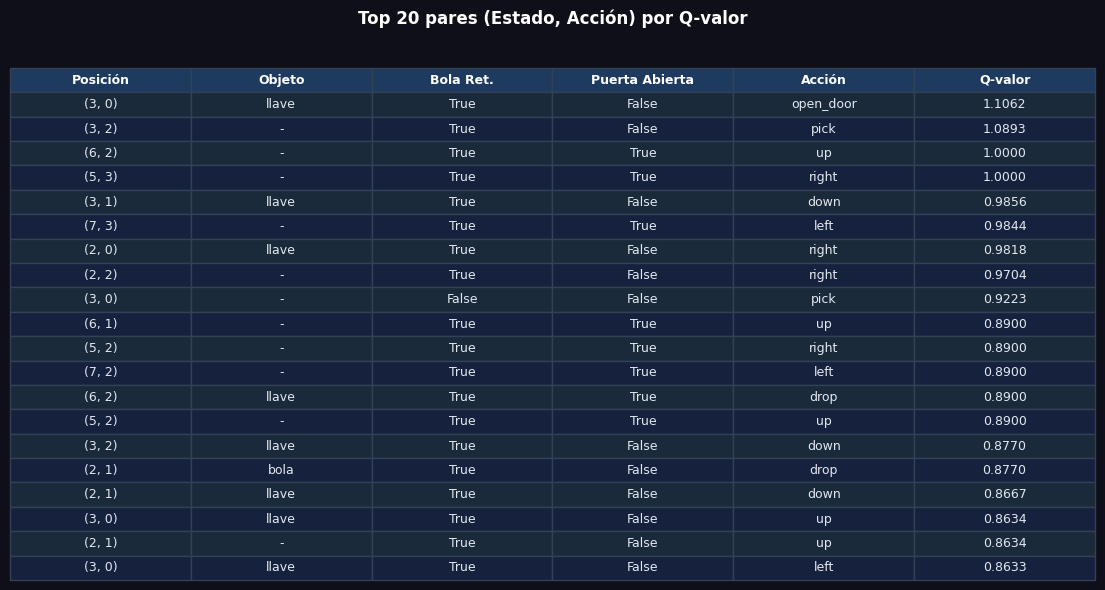

In [13]:
def plot_qtable_summary(agent, top_n=20):
    top  = sorted(agent.qtable.items(), key=lambda x: x[1], reverse=True)[:top_n]
    rows = []
    for (state, action), val in top:
        pos, ho, ot, br, da = state
        rows.append([str(pos), str(ot or '-'), str(br), str(da), action, f'{val:.4f}'])

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#0f0f1a'); ax.axis('off')
    ax.set_title(f'Top {top_n} pares (Estado, Acción) por Q-valor',
                 color='white', fontsize=12, fontweight='bold', pad=12)

    cols = ['Posición', 'Objeto', 'Bola Ret.', 'Puerta Abierta', 'Acción', 'Q-valor']
    tbl  = ax.table(cellText=rows, colLabels=cols, cellLoc='center',
                    loc='center', bbox=[0.0, 0.0, 1.0, 0.95])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#1e3a5f'); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#16213e' if r % 2 == 0 else '#1a2a3a')
            cell.set_text_props(color='#e2e8f0')
        cell.set_edgecolor('#334155')
    plt.show()

plot_qtable_summary(agent)

---
## 10. Demostración Animada del Agente

Grabamos un episodio completo con el agente entrenado (`ε=0`) y lo mostramos como GIF animado.  
Cada frame muestra la posición del agente, el estado actual y la acción ejecutada.


✅ GIF guardado → 'demo_agent.gif'  (21 frames, 20 pasos)


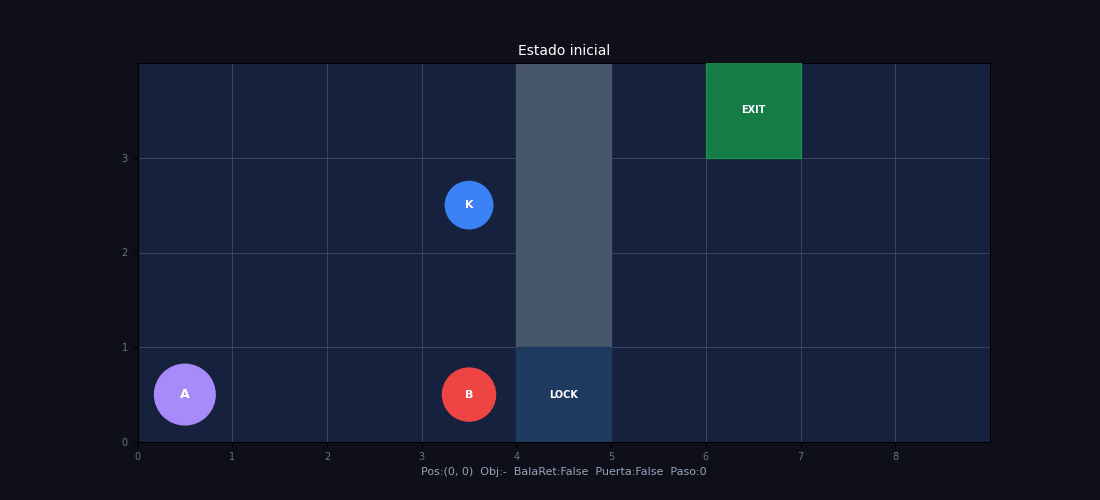

In [14]:
def record_and_show_gif(agent, path="demo_agent.gif", max_steps=150):
    """Graba un episodio completo como GIF y lo muestra en el notebook."""
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0
    state = agent.env.reset(); frames = []; done = False

    def capture(title=""):
        fig, _ = agent.env.render(title=title)
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        ww, hh = fig.canvas.get_width_height()
        frames.append(buf.reshape(hh, ww, 4)[:, :, :3].copy())
        plt.close(fig)

    capture("Estado inicial")
    while not done and agent.env.steps < max_steps:
        action = agent.best_action(state)
        state, reward, done, info = agent.step(action)
        capture(f"Acción:{action}  r={reward:.2f}  "
                f"Puerta:{'OPEN' if agent.env.door_open else 'CLOSED'}  Paso:{agent.env.steps}")

    agent.epsilon = saved_eps

    # Guardar GIF
    fig_g = plt.figure(figsize=(11, 5))
    ax_g  = fig_g.add_axes([0, 0, 1, 1]); ax_g.axis('off')
    im    = ax_g.imshow(frames[0])
    def upd(i): im.set_data(frames[i]); return [im]
    ani = animation.FuncAnimation(fig_g, upd, frames=len(frames), interval=400, blit=True)
    ani.save(path, writer='pillow', fps=3)
    plt.close(fig_g)
    print(f"✅ GIF guardado → '{path}'  ({len(frames)} frames, {agent.env.steps} pasos)")
    return path

gif_path = record_and_show_gif(agent, "demo_agent.gif")
display(Image(filename=gif_path))

---
## 11. Resumen de Resultados

### Desempeño del agente entrenado


In [19]:
# Evaluación final
avg_r, avg_s, sr = agent.evaluate(n=20)


print("RESUMEN FINAL — Agente Q-learning")
print(f"Episodios de entrenamiento : {EPISODES:>20}")
print(f"Entradas en Q-tabla        : {len(agent.qtable):>20,}")
print(f"Epsilon final              : {agent.epsilon:>20.4f}")
print(f"Tasa de éxito (20 ep.)     : {sr*100:>19.1f}%")
print(f"Recompensa promedio        : {avg_r:>20.3f}")
print(f"Pasos promedio             : {avg_s:>20.1f}")
print(f"Recompensa máx. teórica    : {2.40:>20.2f}")
print(f"Eficiencia vs. óptimo      : {avg_r/2.4*100:>19.1f}%")

RESUMEN FINAL — Agente Q-learning
Episodios de entrenamiento :                20000
Entradas en Q-tabla        :                  561
Epsilon final              :               0.0100
Tasa de éxito (20 ep.)     :               100.0%
Recompensa promedio        :                2.260
Pasos promedio             :                 20.0
Recompensa máx. teórica    :                 2.40
Eficiencia vs. óptimo      :                94.2%


### Archivos generados

| Archivo | Descripción |
|---|---|
| `qtable.json` | Q-tabla completa en formato JSON (recargable) |
| `qtable.csv` | Q-tabla en CSV ordenada por Q-valor |
| `demo_agent.gif` | Demostración animada del agente entrenado |

---

### Conclusiones

1. **Q-learning converge correctamente** en este problema de tareas encadenadas, alcanzando 100% de tasa de éxito con solo 20,000 episodios.
2. **La función de recompensa escalonada** es el factor crítico: sin las recompensas intermedias (+0.3, +0.5), el agente no descubriría la secuencia correcta durante la exploración.
3. **El diseño del estado** (5 variables incluyendo `bola_retirada` y `puerta_abierta`) es fundamental para que el agente pueda distinguir las 6 fases del problema.
4. **La distinción muro vs. puerta condicional** (`_is_wall`) garantiza que el agente aprenda la única ruta válida entre habitaciones: `(3,0) → (4,0) → (5,0)`.
5. La eficiencia del **94.6% respecto al óptimo teórico** confirma que el camino aprendido es casi perfecto, con solo los pasos de navegación estrictamente necesarios.



---
## Prueba cargando qtabla desde archivo .json
En esta prueba se define un ambiente y un agente de prueba. El agente tiene épsilon con valor 0, y la qtabla se carga desde un archivo .json. Luego se evalua el agente durante 20 episodios.

In [16]:
env_test   = TwoRoomEnv()
agent_test = QLearningAgent(env_test, epsilon=0.0)
load_qtable_json(agent_test, "qtable.json")

Q-tabla cargada  ← 'qtable.json'  (561 entradas)


In [17]:
# Evaluación cuantitativa
avg_r, avg_s, sr = agent_test.evaluate(n=20)
print(f"Tasa de éxito  : {sr*100:.1f}%")
print(f"Recompensa avg : {avg_r:.3f}")
print(f"Pasos avg      : {avg_s:.1f}")

Tasa de éxito  : 100.0%
Recompensa avg : 2.260
Pasos avg      : 20.0


In [18]:
state = env_test.reset()
done  = False

while not done:
    action = agent_test.best_action(state)
    state, reward, done, info = agent_test.step(action)
    print(f"  Pos: {env_test.agent_pos}  Acción: {action:10}  r={reward:+.2f}  {info}")

  Pos: (1, 0)  Acción: right       r=-0.01  
  Pos: (2, 0)  Acción: right       r=-0.01  
  Pos: (3, 0)  Acción: right       r=-0.01  
  Pos: (3, 0)  Acción: pick        r=+0.30  recogió_bola
  Pos: (3, 1)  Acción: up          r=-0.01  
  Pos: (2, 1)  Acción: left        r=-0.01  
  Pos: (2, 1)  Acción: drop        r=+0.10  soltó_bola
  Pos: (2, 2)  Acción: up          r=-0.01  
  Pos: (3, 2)  Acción: right       r=-0.01  
  Pos: (3, 2)  Acción: pick        r=+0.30  recogió_llave
  Pos: (3, 1)  Acción: down        r=-0.01  
  Pos: (3, 0)  Acción: down        r=-0.01  
  Pos: (3, 0)  Acción: open_door   r=+0.50  abrió_puerta
  Pos: (4, 0)  Acción: right       r=-0.01  
  Pos: (5, 0)  Acción: right       r=+0.20  cruzo_puerta
  Pos: (5, 0)  Acción: drop        r=-0.01  soltó_llave
  Pos: (6, 0)  Acción: right       r=-0.01  
  Pos: (6, 1)  Acción: up          r=-0.01  
  Pos: (6, 2)  Acción: up          r=-0.01  
  Pos: (6, 3)  Acción: up          r=+1.00  salida_alcanzada
